In [1]:
!pip install seaborn

You should consider upgrading via the 'C:\Users\Dell\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
def askQuestion(ind, disorderOffset, disorder_scores):
    question = [random.randint(0,3),random.randint(0,3),random.randint(0,4),random.randint(0,3)]
    question[disorderOffset] = big_array[ind_outer][disorderOffset][ind-1]
    disorder_scores[disorderOffset] += question[disorderOffset]
    return question

In [3]:
anxiety_threshold = [10,9,8,6,5,3,2]
depression_threshold = [10,10,9,8,7,6,4,3,2]
stress_threshold = [23,20,17,16,15,14,12,9,6,3]

In [4]:
import pandas as pd

# Load the 100-row subset CSVs
anxiety_df = pd.read_csv("anxiety_subset.csv")
depression_df = pd.read_csv("depression_subset.csv")
stress_df = pd.read_csv("stress_subset.csv")

assert len(anxiety_df) == len(depression_df) == len(stress_df) == 100, \
    "All CSVs must have exactly 100 rows"

# Put data into big_array
big_array = []

for i in range(len(anxiety_df)):
    anxiety_scores = anxiety_df.iloc[i, 7:-2].astype(int).tolist()
    depression_scores = depression_df.iloc[i, 7:-2].astype(int).tolist()
    stress_scores = stress_df.iloc[i, 7:-2].astype(int).tolist()
    
    big_array.append([anxiety_scores, depression_scores, stress_scores])

print("Total samples in big_array:", len(big_array))
print("Top sample in big_array:", big_array[0])

Total samples in big_array: 100
Top sample in big_array: [[2, 2, 2, 2, 2, 2, 2], [2, 3, 2, 2, 2, 2, 2, 3, 3], [2, 2, 2, 2, 3, 3, 2, 2, 2, 2]]


In [5]:
anxiety_values_steps = []
depression_values_steps = []
stress_values_steps = []
anxiety_pred = []
depression_pred = []
stress_pred = []
normal_pred = []

In [6]:
from gym import Env
from gym.spaces import Discrete, MultiDiscrete
import numpy as np
import random

In [7]:
ind_outer = 0

In [8]:
class ChatBotEnv(Env):
  def __init__(self):
    self.action_space = Discrete(4)
    self.ind_outer = 0
    self.observation_space = MultiDiscrete([4,4,5,4])
    self.state = [random.randint(0,3),random.randint(0,3),random.randint(0,4),random.randint(0,3)]
    self.anxiety_question_offset = 7
    self.depression_question_offset = 9
    self.stress_question_offset = 10
    self.anxiety_score = 0
    self.depression_score = 0
    self.stress_score = 0
    self.anxiety_predicted = False
    self.depression_predicted = False
    self.stress_predicted = False
    self.disorder_scores = [0,0,0]

  def step(self, action):
    done = False
      
    # Ask Anxiety
    if action == 0:
        if self.anxiety_question_offset == -1:
            reward = -5
        elif self.anxiety_question_offset == 0 and self.anxiety_score >= anxiety_threshold[0]:
            self.anxiety_predicted = True
            self.anxiety_question_offset = -1
            reward = 10
        elif self.anxiety_question_offset == 7 or self.anxiety_score >= anxiety_threshold[self.anxiety_question_offset]:
            self.state = askQuestion(self.anxiety_question_offset, 0, self.disorder_scores)
            self.anxiety_question_offset -= 1;
            self.anxiety_score += self.state[0]
            reward = -1
        else:
            reward = -5
    # Ask Depression
    if action == 1:
        if self.depression_question_offset == -1:
            reward = -5
        elif self.depression_question_offset == 0 and self.depression_score >= depression_threshold[0]:
            self.depression_predicted = True
            self.depression_question_offset = -1
            reward = 10
        elif self.depression_question_offset == 9 or self.depression_score >= depression_threshold[self.depression_question_offset]:
            self.state = askQuestion(self.depression_question_offset, 1, self.disorder_scores)
            self.depression_question_offset -= 1;
            self.depression_score += self.state[1]
            reward = -1
        else:
            reward = -5
    # Ask Stress
    if action == 2:
        if self.stress_question_offset == -1:
            reward = -5
        elif self.stress_question_offset == 0 and self.stress_score >= stress_threshold[0]:
            self.stress_predicted = True
            self.stress_question_offset = -1
            reward = 10
        elif self.stress_question_offset == 10 or self.stress_score >= stress_threshold[self.stress_question_offset]:
            self.state = askQuestion(self.stress_question_offset, 2,self.disorder_scores)
            self.stress_question_offset -= 1;
            self.stress_score += self.state[2]
            reward = -1
        else:
            reward = -5
    else:
        good_to_go = True
        if not self.anxiety_predicted:
            if self.anxiety_question_offset == 7:
                reward = -5
                good_to_go = False
            elif self.anxiety_score >= anxiety_threshold[self.anxiety_question_offset]:
                reward = -5
                good_to_go = False
        if not self.depression_predicted:
            if self.depression_question_offset == 9:
                reward = -5
                good_to_go = False
            elif self.depression_score >= depression_threshold[self.depression_question_offset]:
                reward = -5
                good_to_go = False
        if not self.stress_predicted:
            if self.stress_question_offset == 10:
                reward = -5
                good_to_go = False
            elif self.stress_score >= stress_threshold[self.stress_question_offset]:
                reward = -5
                good_to_go = False
        if good_to_go:
            is_anxiety = 0
            is_depression = 0
            is_stress = 0
            is_normal = 0
            done = True
            if self.anxiety_predicted:
                is_anxiety = 1
                print("Anxiety")
            if self.depression_predicted:
                is_depression = 1
                print("Depression")
            if self.stress_predicted:
                is_stress = 1
                print("Stress")
            if not self.anxiety_predicted and not self.depression_predicted and not self.stress_predicted:
                is_normal = 1
                print("Normal")
            anxiety_values_steps.append(7 - self.anxiety_question_offset)
            depression_values_steps.append(9 - self.depression_question_offset)
            stress_values_steps.append(10 - self.stress_question_offset)
            reward = 20
            global ind_outer
            ind_outer += 1
            anxiety_pred.append(is_anxiety)
            depression_pred.append(is_depression)
            stress_pred.append(is_stress)
            normal_pred.append(is_normal)
            
    info = {}
        
    return self.state, reward, done, info

  def render(self):
    pass

  def reset(self):
    self.disorder_scores = [0,0,0]
    self.state = [random.randint(0,3),random.randint(0,3),random.randint(0,4),random.randint(0,3)]
    self.anxiety_question_offset = 7
    self.depression_question_offset = 9
    self.stress_question_offset = 10
    self.anxiety_score = 0
    self.depression_score = 0
    self.stress_score = 0
    self.anxiety_predicted = False
    self.depression_predicted = False
    self.stress_predicted = False
      
    return self.state

In [9]:
env = ChatBotEnv()

In [11]:
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines.common.policies import MlpLstmPolicy

In [12]:
import os

In [13]:
path = os.path.join("Training_Final","Recurrent_Model_Final")

In [14]:
rl_model = RecurrentPPO.load(path,env)

C:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [15]:
device = "cpu"

Anxiety
Depression
Normal
Anxiety
Depression
Anxiety
Stress
Normal
Anxiety
Depression
Anxiety
Depression
Normal
Anxiety
Depression
Normal
Normal
Anxiety
Depression
Normal
Normal
Normal
Anxiety
Depression
Anxiety
Depression
Normal
Anxiety
Depression
Stress
Anxiety
Depression
Normal
Normal
Normal
Anxiety
Depression
Stress
Normal
Normal
Normal
Normal
Anxiety
Depression
Normal
Normal
Normal
Normal
Anxiety
Depression
Anxiety
Depression
Depression
Normal
Normal
Anxiety
Depression
Anxiety
Depression
Normal
Normal
Anxiety
Anxiety
Anxiety
Normal
Normal
Normal
Anxiety
Anxiety
Depression
Normal
Anxiety
Depression
Normal
Normal
Normal
Normal
Normal
Depression
Anxiety
Normal
Depression
Anxiety
Depression
Stress
Anxiety
Depression
Anxiety
Normal
Normal
Anxiety
Depression
Stress
Normal
Anxiety
Depression
Stress
Normal
Anxiety
Depression
Stress
Normal
Anxiety
Depression
Stress
Anxiety
Depression
Anxiety
Normal
Normal
Anxiety
Depression
Normal
Anxiety
Depression
Depression
Anxiety
Depression
Anxiety
De

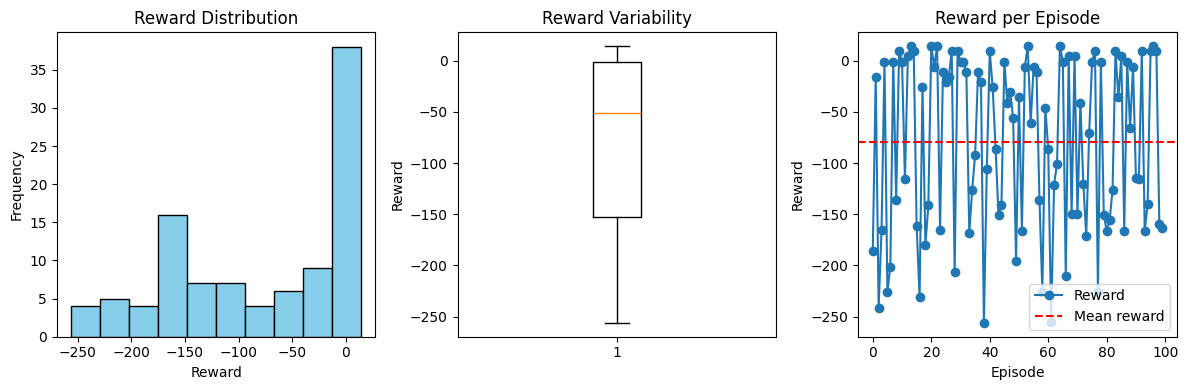

Mean reward: -79.19
Std reward: 82.97
Mean episode length: 22.80


In [16]:
import gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO  # change to your algo

# Evaluation parameters
n_eval_episodes = 100
episode_rewards = []
episode_lengths = []

for ep in range(n_eval_episodes):
    obs = env.reset()
    done = False
    total_reward = 0
    length = 0
    
    while not done:
        action, _ = rl_model.predict(obs)
        obs, reward, done, info = env.step(action)
        total_reward += reward
        length += 1
    
    episode_rewards.append(total_reward)
    episode_lengths.append(length)

# Convert to numpy for easier math
episode_rewards = np.array(episode_rewards)
episode_lengths = np.array(episode_lengths)

# ---------------- PLOTS ----------------

# 1. Histogram of rewards
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(episode_rewards, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.title('Reward Distribution')

# 2. Boxplot of rewards
plt.subplot(1,3,2)
plt.boxplot(episode_rewards, vert=True)
plt.ylabel('Reward')
plt.title('Reward Variability')

# 3. Reward per episode
plt.subplot(1,3,3)
plt.plot(episode_rewards, marker='o', label='Reward')
plt.axhline(np.mean(episode_rewards), color='red', linestyle='--', label='Mean reward')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward per Episode')
plt.legend()

plt.tight_layout()
plt.show()

# Print stats
print(f"Mean reward: {np.mean(episode_rewards):.2f}")
print(f"Std reward: {np.std(episode_rewards):.2f}")
print(f"Mean episode length: {np.mean(episode_lengths):.2f}")

In [17]:
sum_array = []

for entry in big_array:
    anxiety_sum = sum(entry[0])
    depression_sum = sum(entry[1])
    stress_sum = sum(entry[2])
    
    sum_array.append([anxiety_sum, depression_sum, stress_sum])

In [18]:
gad_baseline = []
for arr in sum_array:
    if arr[0] >= 10:
        gad_baseline.append(1)
    else:
        gad_baseline.append(0)

In [19]:
phq_baseline = []
for arr in sum_array:
    if arr[1] >= 10:
        phq_baseline.append(1)
    else:
        phq_baseline.append(0)

In [20]:
pss_baseline = []
for arr in sum_array:
    if arr[2] >= 27:
        pss_baseline.append(1)
    else:
        pss_baseline.append(0)


Confusion Matrix
                    Predicted No Anxiety    Predicted Anxiety
Actual No Anxiety          47                    0
Actual Anxiety             9                    44

Evaluation Metrics
Accuracy     : 0.9100
Precision    : 1.0000
Recall       : 0.8302
F1 Score     : 0.9072
Specificity  : 1.0000

Detailed Classification Report
              precision    recall  f1-score   support

  No Anxiety       0.84      1.00      0.91        47
     Anxiety       1.00      0.83      0.91        53

    accuracy                           0.91       100
   macro avg       0.92      0.92      0.91       100
weighted avg       0.92      0.91      0.91       100



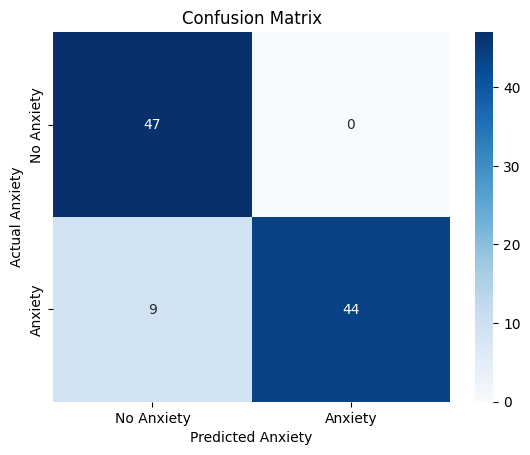

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(gad_baseline, anxiety_pred)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix")
print("                    Predicted No Anxiety    Predicted Anxiety")
print(f"Actual No Anxiety          {tn}                    {fp}")
print(f"Actual Anxiety             {fn}                    {tp}")

# Metrics
accuracy = accuracy_score(gad_baseline, anxiety_pred)
precision = precision_score(gad_baseline, anxiety_pred)
recall = recall_score(gad_baseline, anxiety_pred)
f1 = f1_score(gad_baseline, anxiety_pred)

# Specificity (important in medical cases)
specificity = tn / (tn + fp)

print("\nEvaluation Metrics")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"Specificity  : {specificity:.4f}")

# Full classification report
print("\nDetailed Classification Report")
print(classification_report(gad_baseline, anxiety_pred,
                            target_names=["No Anxiety", "Anxiety"]))

# Heatmap
sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=["No Anxiety", "Anxiety"],
            yticklabels=["No Anxiety", "Anxiety"],
            cmap="Blues")

plt.xlabel("Predicted Anxiety")
plt.ylabel("Actual Anxiety")
plt.title("Confusion Matrix")
plt.show()


Confusion Matrix
                    Predicted No Depression    Predicted Depression
Actual No Depression          45                    0
Actual Depression             16                    39

Evaluation Metrics
Accuracy     : 0.8400
Precision    : 1.0000
Recall       : 0.7091
F1 Score     : 0.8298
Specificity  : 1.0000

Detailed Classification Report
              precision    recall  f1-score   support

  No Anxiety       0.74      1.00      0.85        45
     Anxiety       1.00      0.71      0.83        55

    accuracy                           0.84       100
   macro avg       0.87      0.85      0.84       100
weighted avg       0.88      0.84      0.84       100



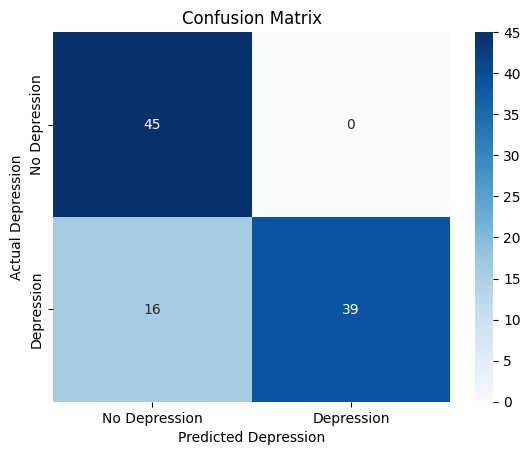

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(phq_baseline, depression_pred)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix")
print("                    Predicted No Depression    Predicted Depression")
print(f"Actual No Depression          {tn}                    {fp}")
print(f"Actual Depression             {fn}                    {tp}")

# Metrics
accuracy = accuracy_score(phq_baseline, depression_pred)
precision = precision_score(phq_baseline, depression_pred)
recall = recall_score(phq_baseline, depression_pred)
f1 = f1_score(phq_baseline, depression_pred)

# Specificity (important in medical cases)
specificity = tn / (tn + fp)

print("\nEvaluation Metrics")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"Specificity  : {specificity:.4f}")

# Full classification report
print("\nDetailed Classification Report")
print(classification_report(phq_baseline, depression_pred,
                            target_names=["No Anxiety", "Anxiety"]))

# Heatmap
sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=["No Depression", "Depression"],
            yticklabels=["No Depression", "Depression"],
            cmap="Blues")

plt.xlabel("Predicted Depression")
plt.ylabel("Actual Depression")
plt.title("Confusion Matrix")
plt.show()


Confusion Matrix
                    Predicted No Stress    Predicted Stress
Actual No Stress          85                    0
Actual Stress             4                    11

Evaluation Metrics
Accuracy     : 0.9600
Precision    : 1.0000
Recall       : 0.7333
F1 Score     : 0.8462
Specificity  : 1.0000

Detailed Classification Report
              precision    recall  f1-score   support

  No Anxiety       0.96      1.00      0.98        85
     Anxiety       1.00      0.73      0.85        15

    accuracy                           0.96       100
   macro avg       0.98      0.87      0.91       100
weighted avg       0.96      0.96      0.96       100



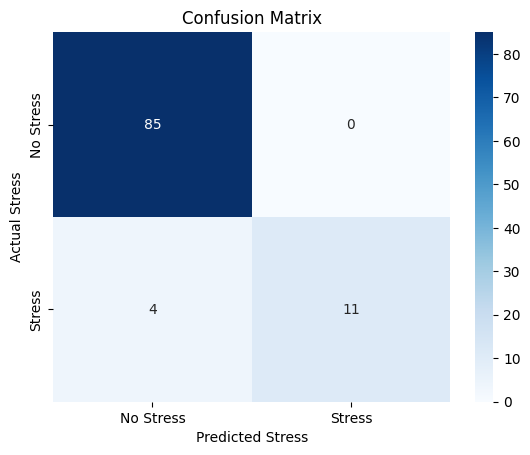

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(pss_baseline, stress_pred)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix")
print("                    Predicted No Stress    Predicted Stress")
print(f"Actual No Stress          {tn}                    {fp}")
print(f"Actual Stress             {fn}                    {tp}")

# Metrics
accuracy = accuracy_score(pss_baseline, stress_pred)
precision = precision_score(pss_baseline, stress_pred)
recall = recall_score(pss_baseline, stress_pred)
f1 = f1_score(pss_baseline, stress_pred)

# Specificity (important in medical cases)
specificity = tn / (tn + fp)

print("\nEvaluation Metrics")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"Specificity  : {specificity:.4f}")

# Full classification report
print("\nDetailed Classification Report")
print(classification_report(pss_baseline, stress_pred,
                            target_names=["No Anxiety", "Anxiety"]))

# Heatmap
sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=["No Stress", "Stress"],
            yticklabels=["No Stress", "Stress"],
            cmap="Blues")

plt.xlabel("Predicted Stress")
plt.ylabel("Actual Stress")
plt.title("Confusion Matrix")
plt.show()